# PatchTST Future Exogenous Compare

이 notebook은 Walmart weekly 데이터에서 아래 모델을 같은 조건으로 비교합니다.

- `patchtst_no_future`
- `patchtst_head_flatten` (기존 방식)
- `patchtst_token_cross_attn` (새 방식)
- `timexer`
- `exotst`

목적은 `PatchTST`의 future exogenous 결합 방식 변경 전후를 직접 비교하고,
필요하면 `timexer`, `exotst`와도 같이 baseline 비교를 보는 것입니다.


In [1]:
from __future__ import annotations

import argparse
import sys
from pathlib import Path
import os
import polars as pl
REPO_ROOT_OVERRIDE = None
import importlib.util


def _looks_like_repo(path: Path) -> bool:
    return (path / 'pyproject.toml').exists() and (path / 'src').exists()


def _iter_named_repo_candidates(root: Path, repo_name: str = 'ts_forecaster_lib', max_depth: int = 4):
    if not root.exists() or not root.is_dir():
        return
    try:
        root_resolved = root.resolve()
    except Exception:
        root_resolved = root
    stack = [(root_resolved, 0)]
    while stack:
        current, depth = stack.pop()
        if current.name == repo_name:
            yield current
        if depth >= max_depth:
            continue
        try:
            children = list(current.iterdir())
        except Exception:
            continue
        for child in children:
            if child.is_dir() and not child.name.startswith('.'):
                stack.append((child, depth + 1))


def find_repo_root(start: Path, explicit_repo_root: Path | None = None) -> Path | None:
    env_repo_root = os.environ.get('TS_FORECASTER_REPO_ROOT')
    candidates = []
    if explicit_repo_root is not None:
        candidates.append(Path(explicit_repo_root).expanduser().resolve())
    if env_repo_root:
        candidates.append(Path(env_repo_root).expanduser().resolve())
    candidates.extend([start, *start.parents])

    home = Path.home()
    common_roots = [
        home,
        home / 'workspace',
        home / 'workspaces',
        home / 'projects',
        home / 'PycharmProjects',
        Path('/workspace'),
        Path('/workspaces'),
        Path('/home'),
        Path('/root'),
    ]
    for root in common_roots:
        candidates.extend(_iter_named_repo_candidates(root))

    seen = set()
    for candidate in candidates:
        if candidate in seen:
            continue
        seen.add(candidate)
        if _looks_like_repo(candidate):
            return candidate
    return None


def resolve_import_paths() -> tuple[Path | None, Path | None]:
    repo_root = find_repo_root(Path.cwd().resolve(), explicit_repo_root=REPO_ROOT_OVERRIDE)
    src_root = repo_root / 'src' if repo_root is not None else None
    if src_root is not None and str(src_root) not in sys.path:
        sys.path.insert(0, str(src_root))

    spec = importlib.util.find_spec('modeling_module')
    if spec is None or spec.origin is None:
        raise RuntimeError(
            'Could not import modeling_module. Set REPO_ROOT_OVERRIDE, TS_FORECASTER_REPO_ROOT, or install the package.'
        )

    module_init = Path(spec.origin).resolve()
    module_root = module_init.parent
    if repo_root is None and module_root.parent.name == 'src':
        repo_root = module_root.parent.parent
        src_root = repo_root / 'src'
    return repo_root, src_root


NOTEBOOK_DIR = Path.cwd().resolve()
REPO_ROOT, SRC_ROOT = resolve_import_paths()

from exogenous_test.run_patchtst_future_fusion_compare import (
    CompareSpec,
    _build_data_request,
    _configure_torch_runtime,
    _default_specs,
    _load_walmart_frame,
    _run_single_model,
    set_global_seed,
)
from model_test.exogenous_test.exogenous_ab_utils import (
    compute_metric_tables,
    ensure_dir,
    plot_latest_revision_aggregate,
    plot_latest_revision_part_grid,
    plot_metric_summary,
    resolve_single_plan_week,
    save_json,
    select_eval_ids_with_full_actual_coverage,
    select_latest_revision,
    select_plot_parts,
)
from modeling_module.api.data import build_datamodule

print('REPO_ROOT:', REPO_ROOT)


REPO_ROOT: /home/leekwanhyeong/workspace/ts_forecaster_lib


## Config

여기서 plan week, epoch, baseline 포함 여부를 조절합니다.

In [2]:
PARQUET_PATH = REPO_ROOT / 'raw_data' / 'train_data' / 'walmart_best_feature_train.parquet'
artifact_root = REPO_ROOT / 'artifacts' / 'exogenous_test' / 'patchtst_future_fusion_compare'
ensure_dir(artifact_root)

include_baselines = True
model_specs = _default_specs(include_baselines=include_baselines)

lookback = 52
horizon = 13
plan_week = 201231
plot_part_count = 12
max_parts_per_plan = 10_000

train_batch_size = 128
infer_batch_size = 64
num_workers = 0
pin_memory = False
persistent_workers = False
prefetch_factor = 2
seed = 22

warmup_epochs = 30
spike_epochs = 5
lr = 1e-3
use_intermittent = False
val_use_weights = False

patch_len = 13
stride = 6
patchtst_d_model = 64
patchtst_layers = 3
patchtst_d_ff = 128
patchtst_future_exo_fusion_dropout = 0.1

timexer_patch_len = 13
timexer_d_model = 128
timexer_heads = 8
timexer_d_ff = 256
timexer_e_layers = 3
timexer_dropout = 0.1
timexer_factor = 5
timexer_activation = 'gelu'
timexer_use_norm = True

exotst_d_model = 128
exotst_heads = 8
exotst_d_ff = 256
exotst_dropout = 0.1
exotst_attn_dropout = 0.1
exotst_exo_enc_layers = 2
exotst_fusion_layers = 2
exotst_endo_dec_layers = 2
exotst_exo_memory_mode = 'all'
exotst_exo_nan_policy = 'zero+indicator'
exotst_use_revin = True
exotst_subtract_last = True

set_global_seed(seed)
device, device_note = _configure_torch_runtime()
run_root = ensure_dir(artifact_root / f'lb{lookback}_h{horizon}_pw{plan_week}')

print('PARQUET_PATH   :', PARQUET_PATH)
print('artifact_root  :', run_root)
print('model_specs    :', [s.label for s in model_specs])
print('lookback       :', lookback)
print('horizon        :', horizon)
print('plan_week      :', plan_week)
print('device         :', device)
if device_note:
    print('device_note    :', device_note)


PARQUET_PATH   : /home/leekwanhyeong/workspace/ts_forecaster_lib/raw_data/train_data/walmart_best_feature_train.parquet
artifact_root  : /home/leekwanhyeong/workspace/ts_forecaster_lib/artifacts/exogenous_test/patchtst_future_fusion_compare/lb52_h13_pw201231
model_specs    : ['patchtst_no_future', 'patchtst_token_cross_attn', 'timexer', 'exotst']
lookback       : 52
horizon        : 13
plan_week      : 201231
device         : cuda


## Data Preparation

In [3]:
ID_COL = 'unique_id'
DATE_COL = 'date'
Y_COL = 'y'
FREQ = 'weekly'

df = _load_walmart_frame(PARQUET_PATH)
target_df = df.select([ID_COL, DATE_COL, Y_COL])

past_exo_cont_cols = [c for c in df.columns if c.startswith('exo_p_')] + [c for c in df.columns if c.startswith('exo_c_')]
past_exo_cat_cols = []
future_exo_cont_cols = [
    c for c in df.columns
    if c.startswith('exo_') and not c.startswith('exo_p_') and not c.startswith('exo_c_')
]

plan_week = resolve_single_plan_week(
    target_df,
    date_col=DATE_COL,
    horizon=horizon,
    plan_week=plan_week,
)

eval_ids = select_eval_ids_with_full_actual_coverage(
    target_df,
    id_col=ID_COL,
    date_col=DATE_COL,
    plan_weeks=[plan_week],
    horizon=horizon,
)

eval_target_df = target_df.filter(pl.col(ID_COL).cast(pl.String).is_in(eval_ids))
train_one_table = df.filter(pl.col(DATE_COL) < int(plan_week))
infer_one_table = df.filter(pl.col(ID_COL).cast(pl.String).is_in(eval_ids))

print('df shape             :', df.shape)
print('target_df shape      :', target_df.shape)
print('train_one_table      :', train_one_table.shape)
print('infer_one_table      :', infer_one_table.shape)
print('eval_target_df       :', eval_target_df.shape)
print('eval_id_count        :', len(eval_ids))
print('plan_week            :', plan_week)
print('past_exo_cont_cols   :', len(past_exo_cont_cols), past_exo_cont_cols)
print('future_exo_cont_cols :', len(future_exo_cont_cols), future_exo_cont_cols)


df shape             : (6435, 38)
target_df shape      : (6435, 3)
train_one_table      : (5850, 38)
infer_one_table      : (6435, 38)
eval_target_df       : (6435, 3)
eval_id_count        : 45
plan_week            : 201231
past_exo_cont_cols   : 18 ['exo_p_y_lag_1w', 'exo_p_y_lag_2w', 'exo_p_y_lag_52w', 'exo_p_y_rollmean_4w', 'exo_p_y_rollmean_12w', 'exo_p_y_rollstd_4w', 'exo_p_weeks_since_holiday', 'exo_p_temperature', 'exo_p_fuel_price', 'exo_p_cpi', 'exo_p_unemployment', 'exo_p_markdown_sum', 'exo_p_markdown1', 'exo_p_markdown2', 'exo_p_markdown3', 'exo_p_markdown4', 'exo_p_markdown5', 'exo_c_woy_bucket']
future_exo_cont_cols : 16 ['exo_is_holiday', 'exo_temperature', 'exo_fuel_price', 'exo_cpi', 'exo_unemployment', 'exo_markdown_sum', 'exo_markdown1', 'exo_markdown2', 'exo_markdown3', 'exo_markdown4', 'exo_markdown5', 'exo_markdown1_isnull', 'exo_markdown2_isnull', 'exo_markdown3_isnull', 'exo_markdown4_isnull', 'exo_markdown5_isnull']


## Loader Smoke Test

In [4]:
for spec in model_specs:
    req = _build_data_request(
        df=train_one_table,
        lookback=lookback,
        horizon=horizon,
        batch_size=train_batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=persistent_workers,
        prefetch_factor=prefetch_factor,
        past_exo_cont_cols=past_exo_cont_cols,
        past_exo_cat_cols=past_exo_cat_cols,
        future_exo_cont_cols=future_exo_cont_cols,
        use_future_exogenous=spec.use_future_exogenous,
    )
    dm = build_datamodule(req)
    loader = dm.get_train_loader()
    x, y, uid, future_exo, past_exo_cont, past_exo_cat = next(iter(loader))
    print(f'[{spec.label}] x            :', tuple(x.shape))
    print(f'[{spec.label}] y            :', tuple(y.shape))
    print(f'[{spec.label}] future_exo   :', tuple(future_exo.shape))
    print(f'[{spec.label}] past_exo_cont:', tuple(past_exo_cont.shape))
    print(f'[{spec.label}] past_exo_cat :', tuple(past_exo_cat.shape))
    print('---')


[patchtst_no_future] x            : (128, 52, 1)
[patchtst_no_future] y            : (128, 13)
[patchtst_no_future] future_exo   : (128, 13, 0)
[patchtst_no_future] past_exo_cont: (128, 52, 18)
[patchtst_no_future] past_exo_cat : (128, 52, 0)
---
[patchtst_token_cross_attn] x            : (128, 52, 1)
[patchtst_token_cross_attn] y            : (128, 13)
[patchtst_token_cross_attn] future_exo   : (128, 13, 16)
[patchtst_token_cross_attn] past_exo_cont: (128, 52, 18)
[patchtst_token_cross_attn] past_exo_cat : (128, 52, 0)
---
[timexer] x            : (128, 52, 1)
[timexer] y            : (128, 13)
[timexer] future_exo   : (128, 13, 0)
[timexer] past_exo_cont: (128, 52, 18)
[timexer] past_exo_cat : (128, 52, 0)
---
[exotst] x            : (128, 52, 1)
[exotst] y            : (128, 13)
[exotst] future_exo   : (128, 13, 16)
[exotst] past_exo_cont: (128, 52, 18)
[exotst] past_exo_cat : (128, 52, 0)
---


## Train + Forecast

이 셀은 실제 학습과 추론을 수행합니다.

In [5]:
args = argparse.Namespace(
    parquet_path=PARQUET_PATH,
    artifact_root=artifact_root,
    lookback=lookback,
    horizon=horizon,
    plan_week=plan_week,
    plot_part_count=plot_part_count,
    max_parts_per_plan=max_parts_per_plan,
    train_batch_size=train_batch_size,
    infer_batch_size=infer_batch_size,
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=persistent_workers,
    prefetch_factor=prefetch_factor,
    seed=seed,
    warmup_epochs=warmup_epochs,
    spike_epochs=spike_epochs,
    lr=lr,
    use_intermittent=use_intermittent,
    val_use_weights=val_use_weights,
    ssl_mask_ratio=0.3,
    ssl_loss_type='mse',
    patch_len=patch_len,
    stride=stride,
    patchtst_d_model=patchtst_d_model,
    patchtst_layers=patchtst_layers,
    patchtst_d_ff=patchtst_d_ff,
    patchtst_future_exo_fusion_dropout=patchtst_future_exo_fusion_dropout,
    timexer_patch_len=timexer_patch_len,
    timexer_d_model=timexer_d_model,
    timexer_heads=timexer_heads,
    timexer_d_ff=timexer_d_ff,
    timexer_e_layers=timexer_e_layers,
    timexer_dropout=timexer_dropout,
    timexer_factor=timexer_factor,
    timexer_activation=timexer_activation,
    timexer_use_norm=timexer_use_norm,
    exotst_d_model=exotst_d_model,
    exotst_heads=exotst_heads,
    exotst_d_ff=exotst_d_ff,
    exotst_dropout=exotst_dropout,
    exotst_attn_dropout=exotst_attn_dropout,
    exotst_exo_enc_layers=exotst_exo_enc_layers,
    exotst_fusion_layers=exotst_fusion_layers,
    exotst_endo_dec_layers=exotst_endo_dec_layers,
    exotst_exo_memory_mode=exotst_exo_memory_mode,
    exotst_exo_nan_policy=exotst_exo_nan_policy,
    exotst_use_revin=exotst_use_revin,
    exotst_subtract_last=exotst_subtract_last,
)

results = {}
forecast_tables = []

for spec in model_specs:
    print(f'=== RUN {spec.label} ({spec.request_key}) ===')
    train_result, forecast_df = _run_single_model(
        spec=spec,
        train_df=train_one_table,
        infer_df=infer_one_table,
        eval_target_df=eval_target_df,
        past_exo_cont_cols=past_exo_cont_cols,
        past_exo_cat_cols=past_exo_cat_cols,
        future_exo_cont_cols=future_exo_cont_cols,
        args=args,
        run_root=run_root,
        device=device,
    )
    results[spec.label] = train_result
    forecast_tables.append(forecast_df)
    print(spec.label, 'forecast shape:', forecast_df.shape)

combined_forecast_df = pl.concat(forecast_tables, how='vertical_relaxed') if forecast_tables else pl.DataFrame()
combined_forecast_df.head()


=== RUN patchtst_no_future (patchtst_base) ===
[exo_policy] use_exo=True, use_past=True, use_future=False | future(has=True, dim=0) | past(cont=18, cat=0)
[total_train][EXO] use_exo=True source=past_only exo_dim=0 future_cb=False past_cont=18 past_cat=0

[total_train] === RUN: patchtst (weekly) targets=['patchtst_base'] ===
[SSL] PatchTST Pretrain (Weekly) -> /home/leekwanhyeong/workspace/ts_forecaster_lib/artifacts/exogenous_test/patchtst_future_fusion_compare/lb52_h13_pw201231/patchtst_no_future/pretrain/patchtst_pretrain_best.pt
[train_patchtst_pretrain] Effective TrainingConfig:
{
  "device": "cuda",
  "log_every": 100,
  "lookback": 52,
  "horizon": 13,
  "epochs": 0,
  "lr": 0.001,
  "weight_decay": 0.001,
  "t_max": 40,
  "patience": 100,
  "max_grad_norm": 30.0,
  "amp_device": "cuda",
  "use_amp": true,
  "loss_mode": "auto",
  "point_loss": "mse",
  "huber_delta": 0.8,
  "q_star": 0.5,
  "use_cost_q_star": false,
  "Cu": 2.0,
  "Co": 1.0,
  "quantiles": [
    0.1,
    0.5,
  

model_name,part_no,plan_week,forecast_week,horizon_step,prediction,actual
str,str,i64,i64,i64,f64,f64
"""patchtst_no_future""","""1""",201231,201231,0,1434804.5,1.6311e6
"""patchtst_no_future""","""1""",201231,201232,1,1443787.5,1.59241e6
"""patchtst_no_future""","""1""",201231,201233,2,1.4539e6,1.597868e6
"""patchtst_no_future""","""1""",201231,201234,3,1.405005e6,1.4941e6
"""patchtst_no_future""","""1""",201231,201235,4,1381074.5,1.5821e6


## Metrics and Plots

model_name,n_rows,n_parts,n_plan_weeks,mae,rmse,bias,smape,wape
str,u32,u32,u32,f64,f64,f64,f64,f64
"""patchtst_no_future""",585,45,1,586949.356571,690521.088432,441189.114263,0.543365,0.570509
"""patchtst_token_cross_attn""",585,45,1,587777.259135,692004.719221,446438.518109,0.543835,0.571314
"""timexer""",585,45,1,632799.721528,745651.645721,526161.056571,0.567051,0.615075
"""exotst""",585,45,1,642938.268536,756280.835458,541674.633494,0.572514,0.62493


model_name,n_rows,n_parts,n_target_weeks,mae,rmse,bias,smape,wape
str,u32,u32,u32,f64,f64,f64,f64,f64
"""patchtst_no_future""",585,45,13,586949.356571,690521.088432,441189.114263,0.543365,0.570509
"""patchtst_token_cross_attn""",585,45,13,587777.259135,692004.719221,446438.518109,0.543835,0.571314
"""timexer""",585,45,13,632799.721528,745651.645721,526161.056571,0.567051,0.615075
"""exotst""",585,45,13,642938.268536,756280.835458,541674.633494,0.572514,0.62493


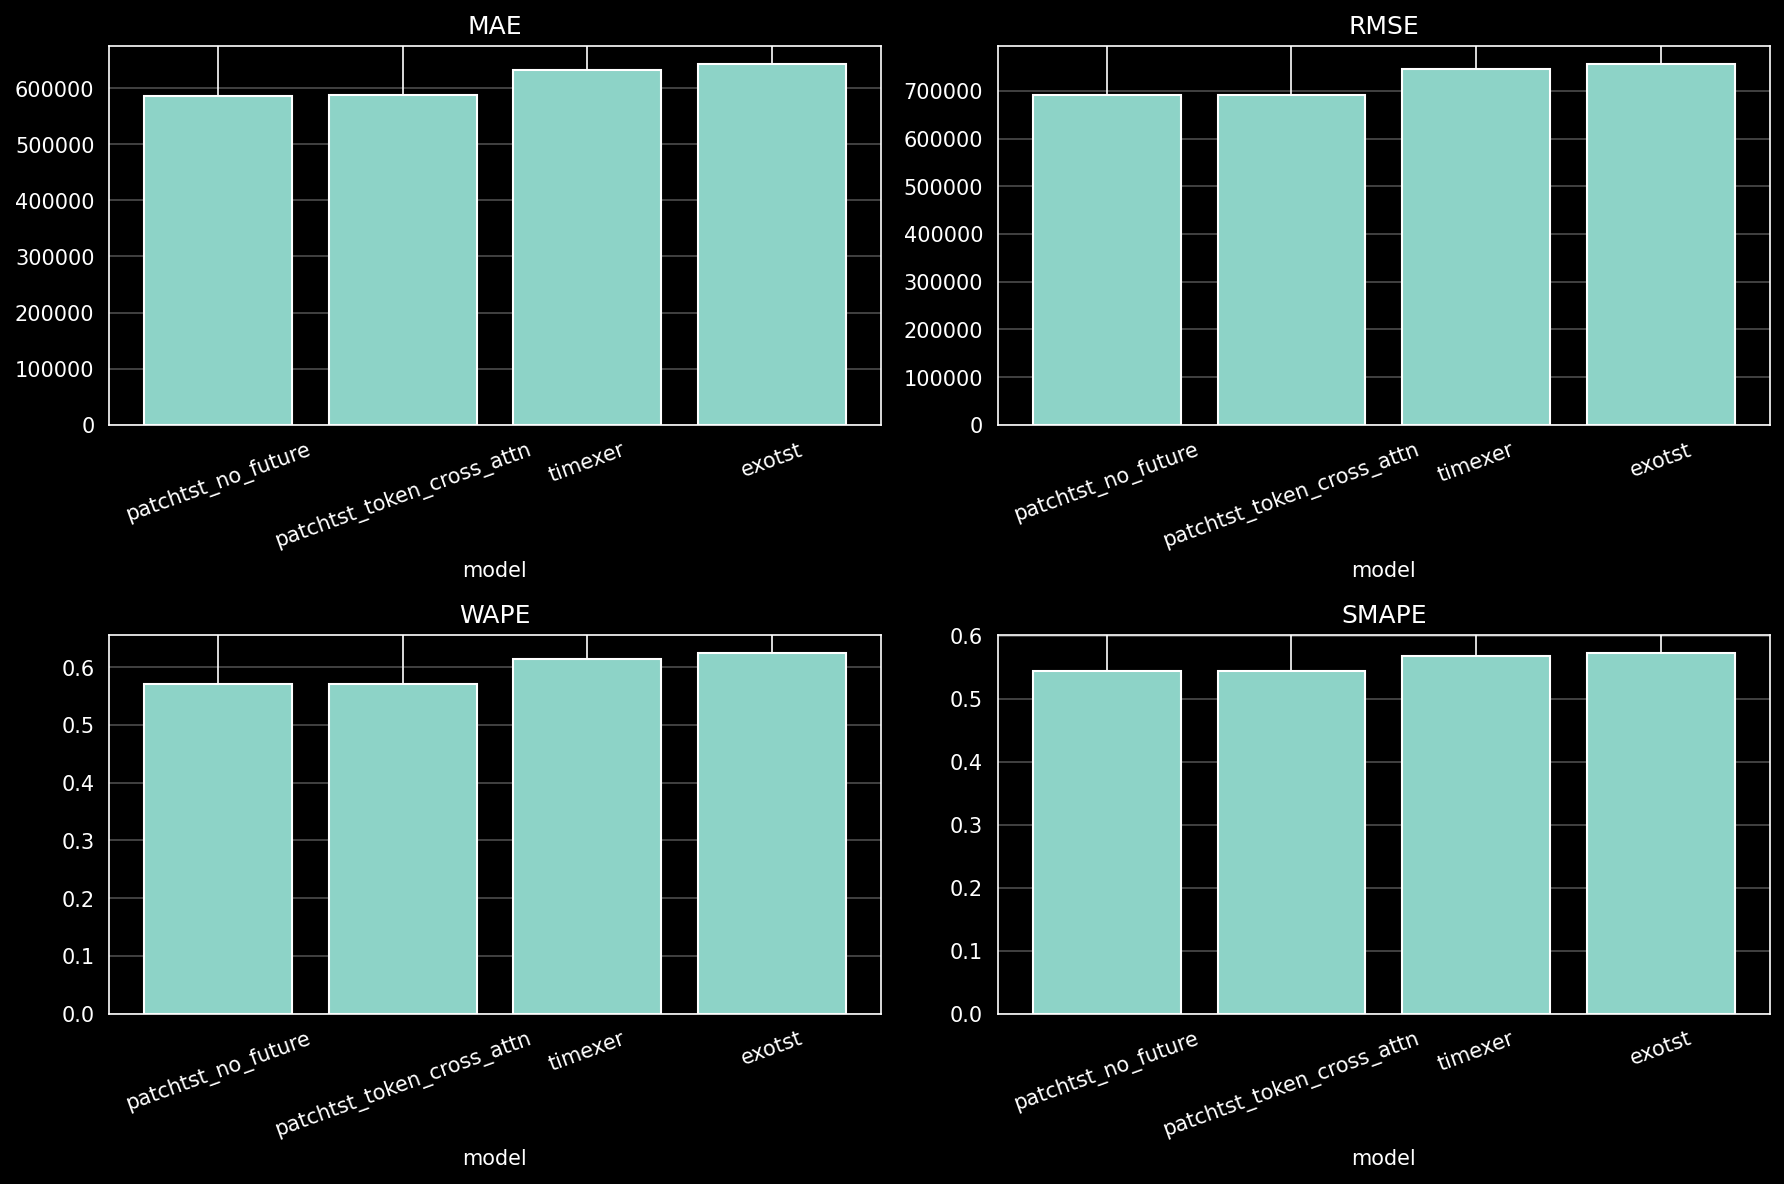

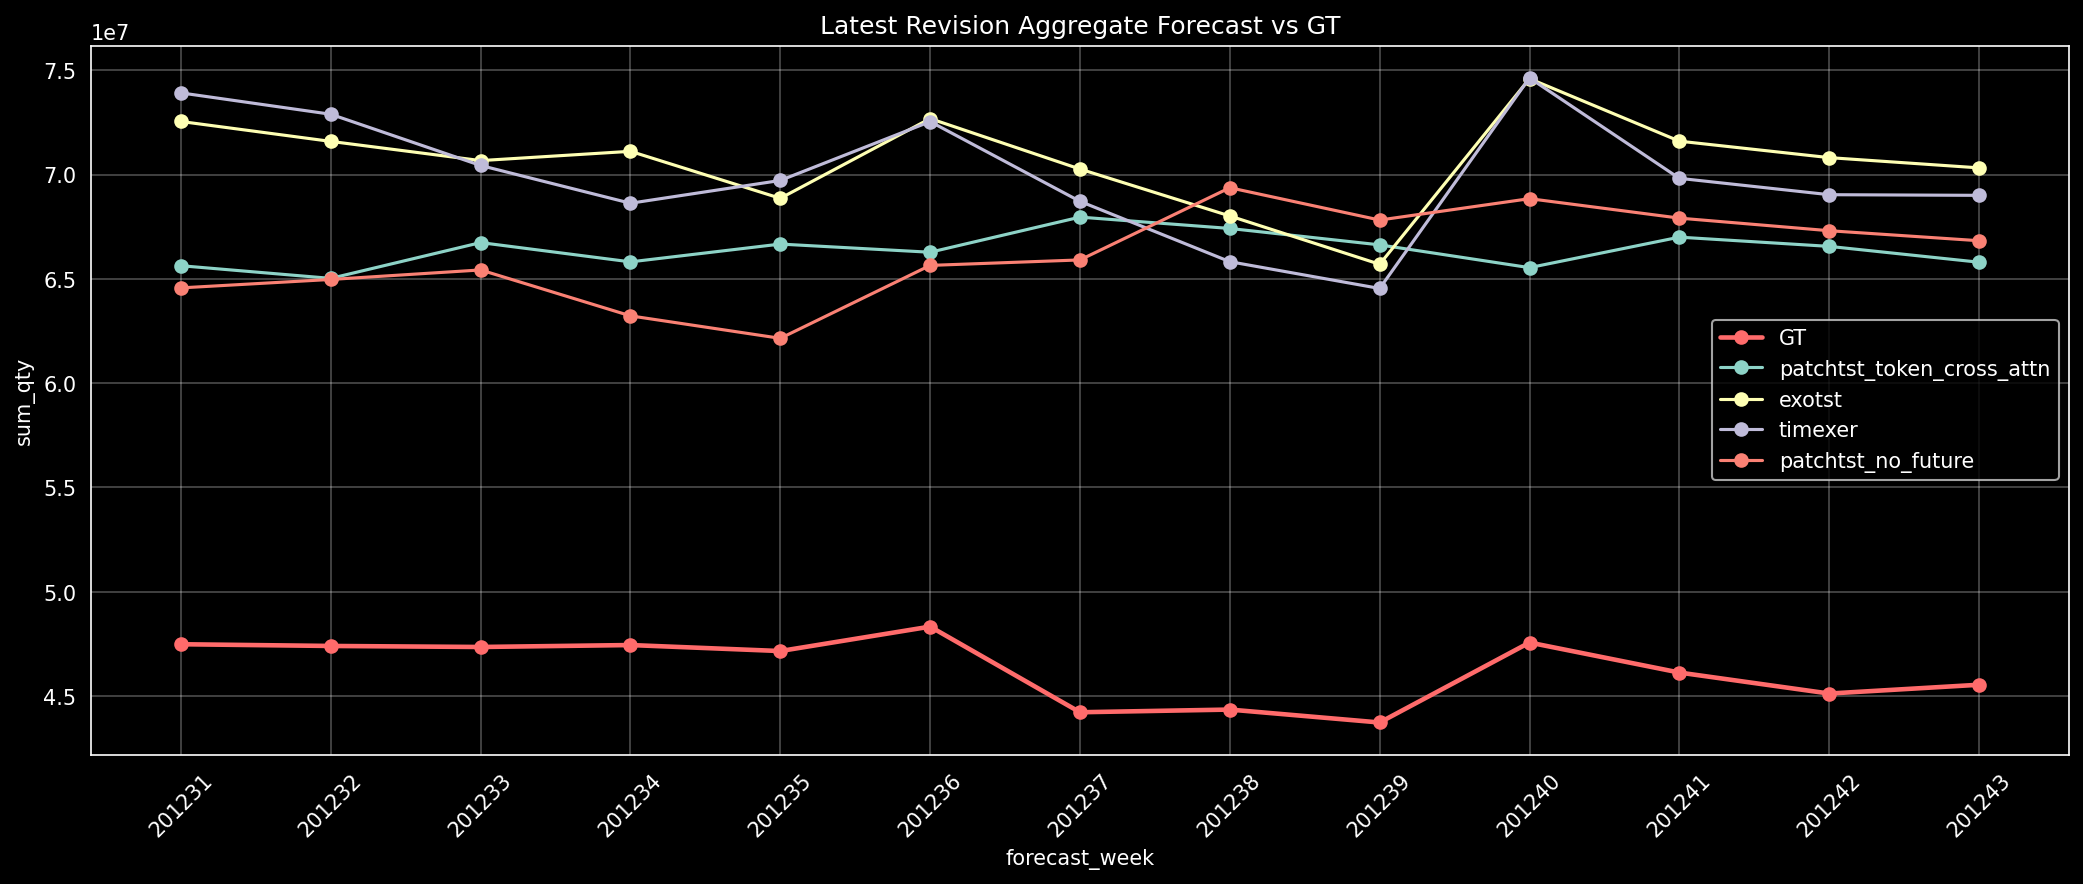

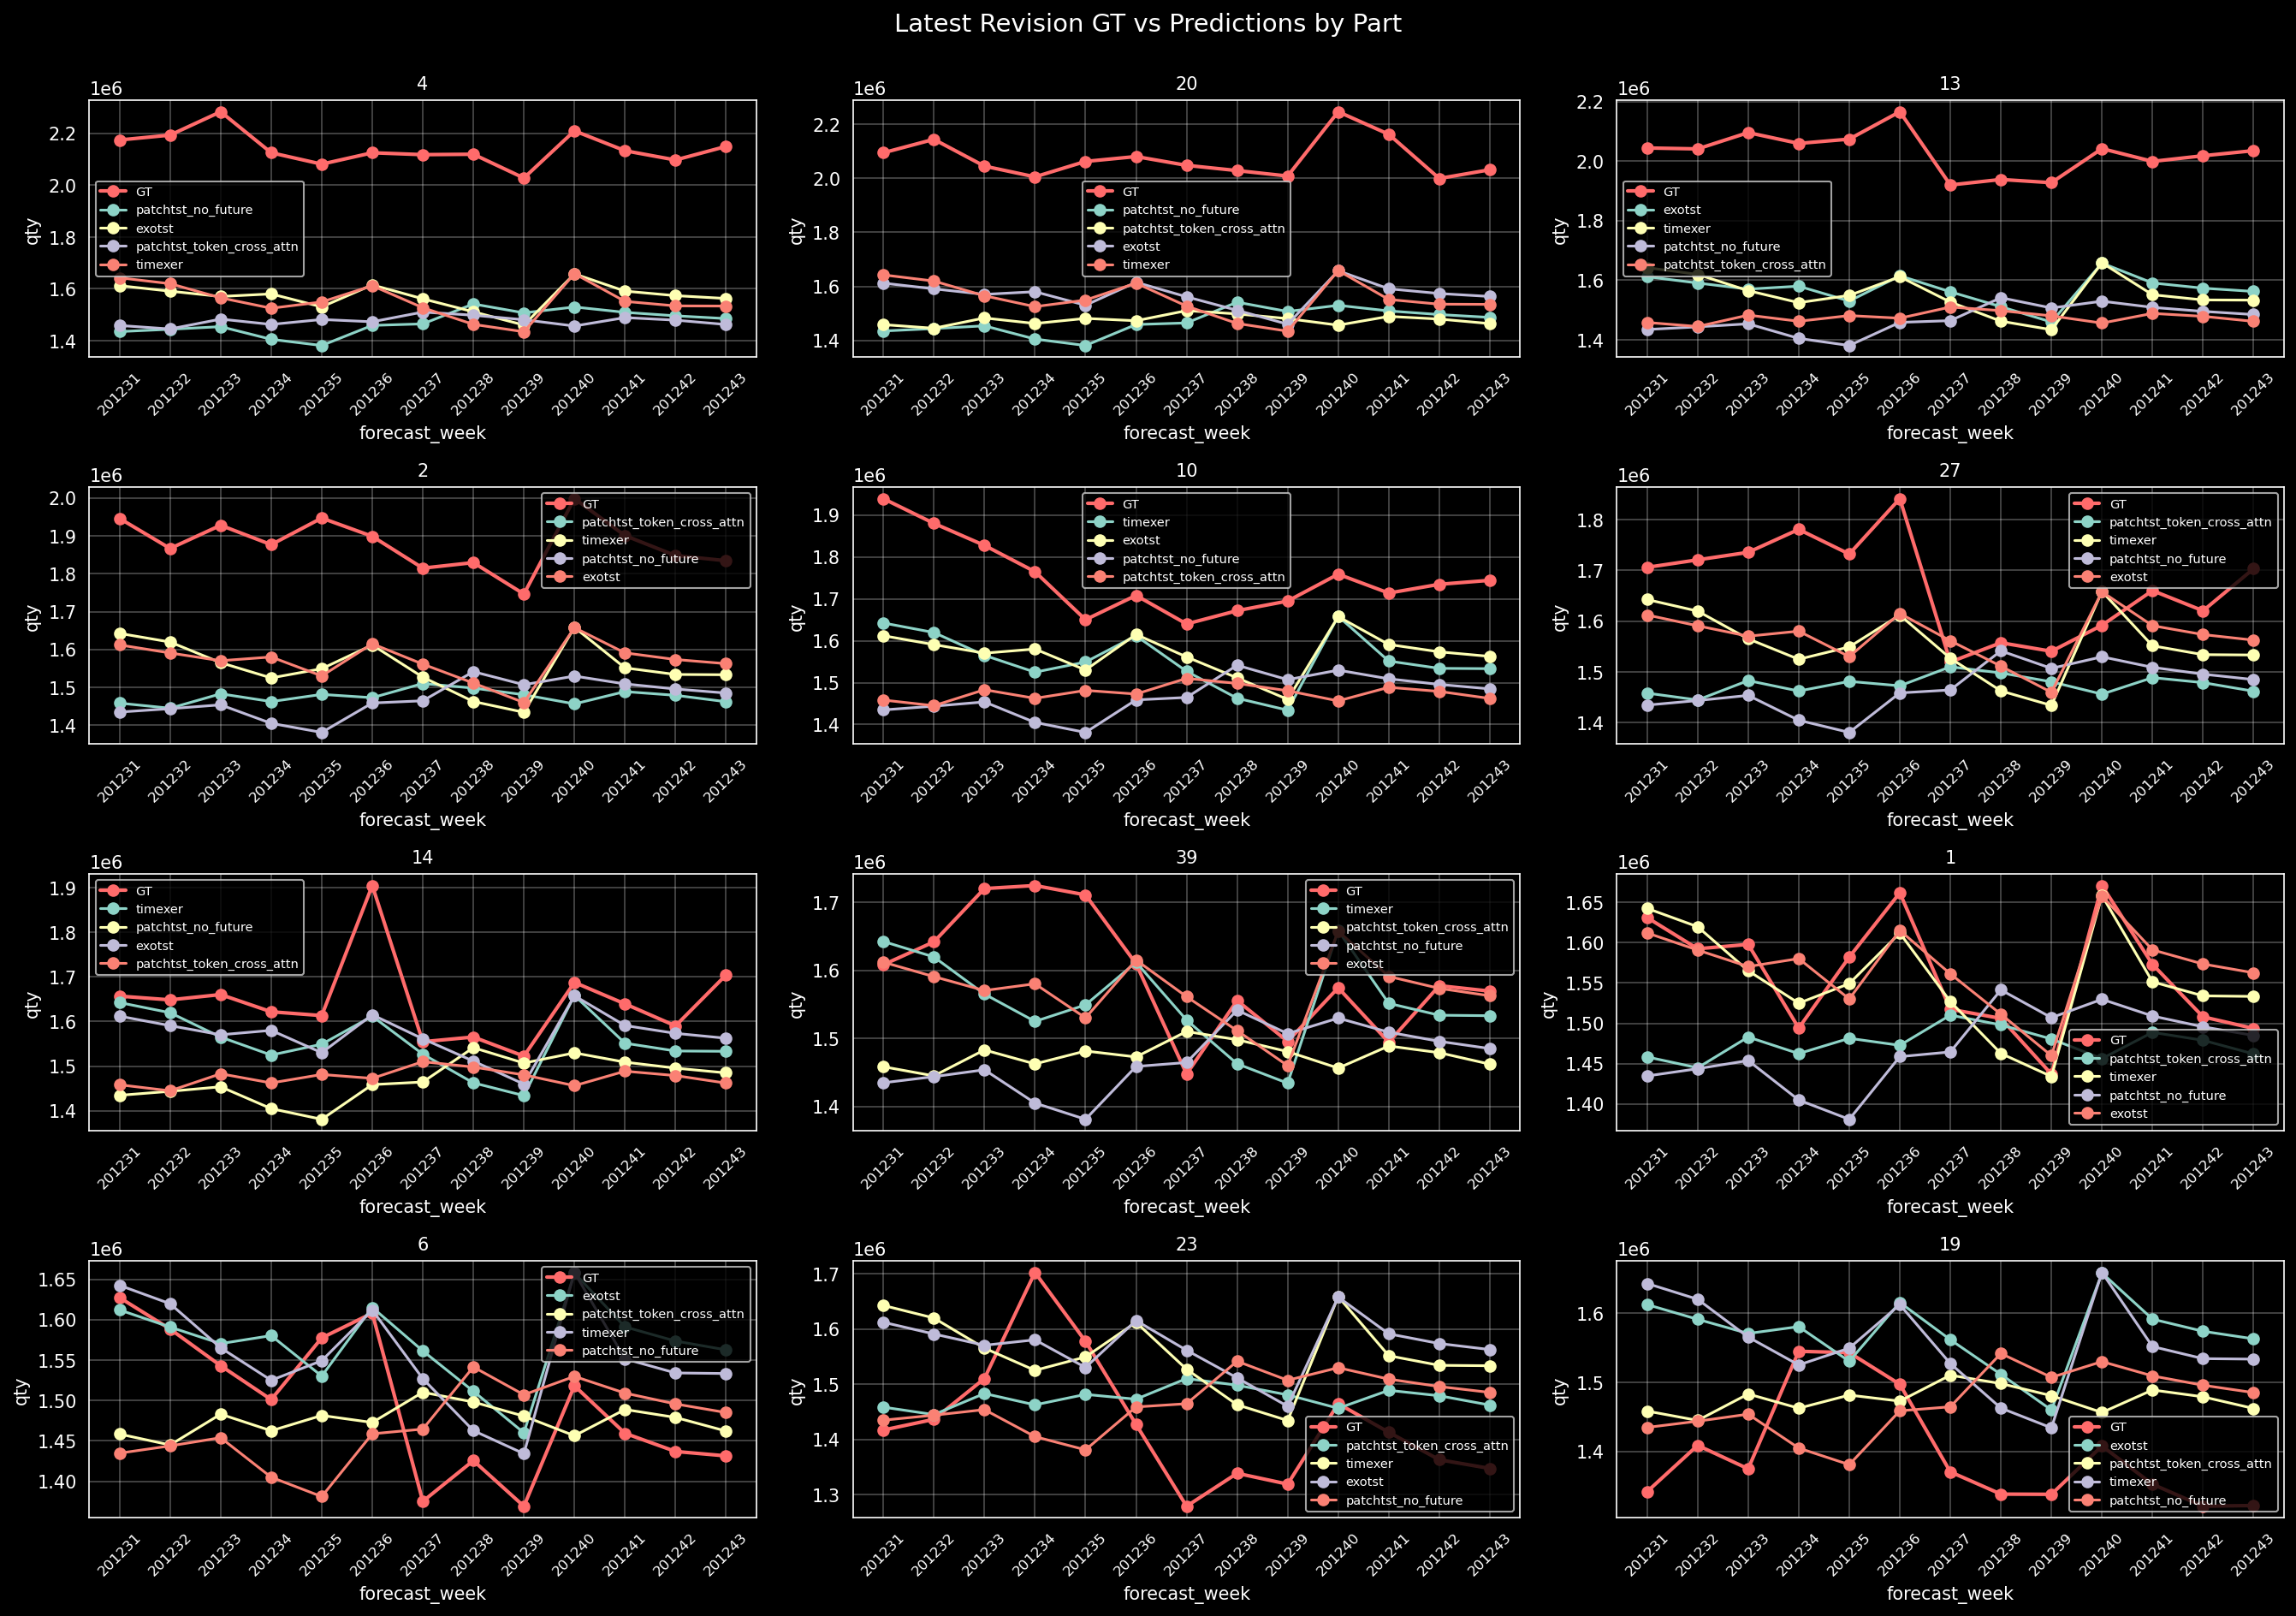

saved forecast       : /home/leekwanhyeong/workspace/ts_forecaster_lib/artifacts/exogenous_test/patchtst_future_fusion_compare/lb52_h13_pw201231/forecast_long.parquet
saved overall        : /home/leekwanhyeong/workspace/ts_forecaster_lib/artifacts/exogenous_test/patchtst_future_fusion_compare/lb52_h13_pw201231/overall_metrics.csv
saved latest summary : /home/leekwanhyeong/workspace/ts_forecaster_lib/artifacts/exogenous_test/patchtst_future_fusion_compare/lb52_h13_pw201231/latest_revision_metrics.csv
saved metric plot    : /home/leekwanhyeong/workspace/ts_forecaster_lib/artifacts/exogenous_test/patchtst_future_fusion_compare/lb52_h13_pw201231/metric_summary.png
saved aggregate plot : /home/leekwanhyeong/workspace/ts_forecaster_lib/artifacts/exogenous_test/patchtst_future_fusion_compare/lb52_h13_pw201231/latest_revision_aggregate.png
saved part plot      : /home/leekwanhyeong/workspace/ts_forecaster_lib/artifacts/exogenous_test/patchtst_future_fusion_compare/lb52_h13_pw201231/latest_revi

In [6]:
from IPython.display import Image, display

overall_df, by_horizon_df, latest_summary_df = compute_metric_tables(combined_forecast_df)
latest_df = select_latest_revision(
    combined_forecast_df.filter(pl.col("actual").is_not_null())
)

forecast_path = run_root / 'forecast_long.parquet'
overall_path = run_root / 'overall_metrics.csv'
latest_summary_path = run_root / 'latest_revision_metrics.csv'
manifest_path = run_root / 'run_manifest.json'
metric_plot_path = run_root / 'metric_summary.png'
agg_plot_path = run_root / 'latest_revision_aggregate.png'
part_plot_path = run_root / 'latest_revision_parts.png'

combined_forecast_df.write_parquet(forecast_path)
overall_df.write_csv(overall_path)
latest_summary_df.write_csv(latest_summary_path)

plot_metric_summary(overall_df, metric_plot_path)
plot_latest_revision_aggregate(latest_df, agg_plot_path)
sampled_parts = select_plot_parts(latest_df, plot_part_count=plot_part_count)
plot_latest_revision_part_grid(
    latest_df,
    sampled_parts=sampled_parts,
    save_path=part_plot_path,
)

save_json(
    {
        'parquet_path': str(PARQUET_PATH),
        'artifact_root': str(run_root),
        'lookback': int(lookback),
        'horizon': int(horizon),
        'plan_week': int(plan_week),
        'device': device,
        'specs': [
            {
                'label': s.label,
                'request_key': s.request_key,
                'use_future_exogenous': bool(s.use_future_exogenous),
                'patchtst_future_exo_fusion_mode': s.patchtst_future_exo_fusion_mode,
            }
            for s in model_specs
        ],
        'paths': {
            'forecast_long': str(forecast_path),
            'overall_metrics': str(overall_path),
            'latest_revision_metrics': str(latest_summary_path),
            'metric_plot': str(metric_plot_path),
            'aggregate_plot': str(agg_plot_path),
            'part_plot': str(part_plot_path),
        },
    },
    manifest_path,
)

display(overall_df)
display(latest_summary_df)

display(Image(filename=str(metric_plot_path)))
display(Image(filename=str(agg_plot_path)))
display(Image(filename=str(part_plot_path)))

print('saved forecast       :', forecast_path)
print('saved overall        :', overall_path)
print('saved latest summary :', latest_summary_path)
print('saved metric plot    :', metric_plot_path)
print('saved aggregate plot :', agg_plot_path)
print('saved part plot      :', part_plot_path)
print('saved manifest       :', manifest_path)
